In [31]:
from pathlib import Path
import cv2
import hashlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Notebook is inside /notebooks
PROJECT_ROOT = Path.cwd().parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"

IMAGE_DIR = RAW_DIR / "images"
ANNOTATION_DIR = RAW_DIR / "Annotations"
PCB_DIR = RAW_DIR / "PCB_USED"

CLEAN_DIR = PROJECT_ROOT / "data" / "clean"
SPLIT_DIR = PROJECT_ROOT / "splits"
RESULT_DIR = PROJECT_ROOT / "results"

CLEAN_DIR.mkdir(parents=True, exist_ok=True)
SPLIT_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:   ", PROJECT_ROOT)
print("Images:         ", IMAGE_DIR)
print("Annotations:    ", ANNOTATION_DIR)
print("PCB references: ", PCB_DIR)

print("\nFolder check:")
print("Images exists:      ", IMAGE_DIR.exists())
print("Annotations exists: ", ANNOTATION_DIR.exists())
print("PCB_USED exists:    ", PCB_DIR.exists())

Project root:    C:\Users\TARUMT\Downloads\PCB-Defect-Inspection
Images:          C:\Users\TARUMT\Downloads\PCB-Defect-Inspection\data\raw\images
Annotations:     C:\Users\TARUMT\Downloads\PCB-Defect-Inspection\data\raw\Annotations
PCB references:  C:\Users\TARUMT\Downloads\PCB-Defect-Inspection\data\raw\PCB_USED

Folder check:
Images exists:       True
Annotations exists:  True
PCB_USED exists:     True


In [4]:
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [6]:
for item in RAW_DIR.iterdir():
    print(item.name, "->", "Folder" if item.is_dir() else "File")

Missing_hole -> Folder
Mouse_bite -> Folder
Open_circuit -> Folder
Short -> Folder
Spur -> Folder
Spurious_copper -> Folder


In [32]:
class_folders = sorted([
    folder for folder in IMAGE_DIR.iterdir()
    if folder.is_dir()
])

print("Classes found:", len(class_folders))

for folder in class_folders:
    print(folder.name)

Classes found: 6
Missing_hole
Mouse_bite
Open_circuit
Short
Spur
Spurious_copper


In [8]:
image_files = []

for class_folder in class_folders:
    for file in class_folder.rglob("*"):
        if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS:
            image_files.append(file)

print("Total images found:", len(image_files))

Total images found: 693


In [33]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

image_files = []

for class_folder in class_folders:
    for file in class_folder.rglob("*"):
        if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS:
            image_files.append(file)

print("Total images found:", len(image_files))

Total images found: 693


In [34]:
corrupted_files = []

for path in image_files:
    image = cv2.imread(str(path))

    if image is None:
        corrupted_files.append(path)

print("Total images:", len(image_files))
print("Corrupted/unreadable:", len(corrupted_files))

Total images: 693
Corrupted/unreadable: 0


In [35]:
annotation_class_folders = sorted([
    folder for folder in ANNOTATION_DIR.iterdir()
    if folder.is_dir()
])

for folder in annotation_class_folders:
    files = [f for f in folder.iterdir() if f.is_file()]

    print(f"\n{folder.name}")
    print("Number of files:", len(files))

    for file in files[:5]:
        print("  ", file.name)


Missing_hole
Number of files: 115
   01_missing_hole_01.xml
   01_missing_hole_02.xml
   01_missing_hole_03.xml
   01_missing_hole_04.xml
   01_missing_hole_05.xml

Mouse_bite
Number of files: 115
   01_mouse_bite_01.xml
   01_mouse_bite_02.xml
   01_mouse_bite_03.xml
   01_mouse_bite_04.xml
   01_mouse_bite_05.xml

Open_circuit
Number of files: 116
   01_open_circuit_01.xml
   01_open_circuit_02.xml
   01_open_circuit_03.xml
   01_open_circuit_04.xml
   01_open_circuit_05.xml

Short
Number of files: 116
   01_short_01.xml
   01_short_02.xml
   01_short_03.xml
   01_short_04.xml
   01_short_05.xml

Spur
Number of files: 115
   01_spur_01.xml
   01_spur_02.xml
   01_spur_03.xml
   01_spur_04.xml
   01_spur_05.xml

Spurious_copper
Number of files: 116
   01_spurious_copper_01.xml
   01_spurious_copper_02.xml
   01_spurious_copper_03.xml
   01_spurious_copper_04.xml
   01_spurious_copper_05.xml


In [12]:
print("Total readable images:", len(image_df))

print("\nImage dimensions:")
print(
    image_df.groupby(["width", "height"])
    .size()
    .sort_values(ascending=False)
    .head(20)
)

print("\nChannels:")
print(image_df["channels"].value_counts())

print("\nFormats:")
print(image_df["extension"].value_counts())

Total readable images: 693

Image dimensions:
width  height
3034   1586      120
3056   2464      120
2868   2316       61
2282   2248       60
2529   2530       60
2544   2156       60
2759   2154       60
2775   2159       60
2904   1921       60
2240   2016       32
dtype: int64

Channels:
channels
3    693
Name: count, dtype: int64

Formats:
extension
.jpg    693
Name: count, dtype: int64


In [13]:
def calculate_hash(path):
    sha256 = hashlib.sha256()

    with open(path, "rb") as file:
        while True:
            chunk = file.read(8192)

            if not chunk:
                break

            sha256.update(chunk)

    return sha256.hexdigest()

In [14]:
hash_groups = {}

for path in image_files:
    file_hash = calculate_hash(path)

    if file_hash not in hash_groups:
        hash_groups[file_hash] = []

    hash_groups[file_hash].append(path)

In [15]:
duplicate_groups = {
    file_hash: paths
    for file_hash, paths in hash_groups.items()
    if len(paths) > 1
}

print("Exact duplicate groups:", len(duplicate_groups))

Exact duplicate groups: 0


In [16]:
for i, paths in enumerate(duplicate_groups.values(), start=1):

    print(f"\nDuplicate Group {i}")

    for path in paths:
        print(" -", path.relative_to(RAW_DIR))

    if i >= 20:
        break

In [17]:
cross_class_duplicates = []

for paths in duplicate_groups.values():

    classes = {
        path.relative_to(RAW_DIR).parts[0]
        for path in paths
    }

    if len(classes) > 1:
        cross_class_duplicates.append(paths)

print("Duplicate groups across different classes:",
      len(cross_class_duplicates))

for paths in cross_class_duplicates[:20]:
    print("\nPotential issue:")

    for path in paths:
        print(" -", path.relative_to(RAW_DIR))

Duplicate groups across different classes: 0


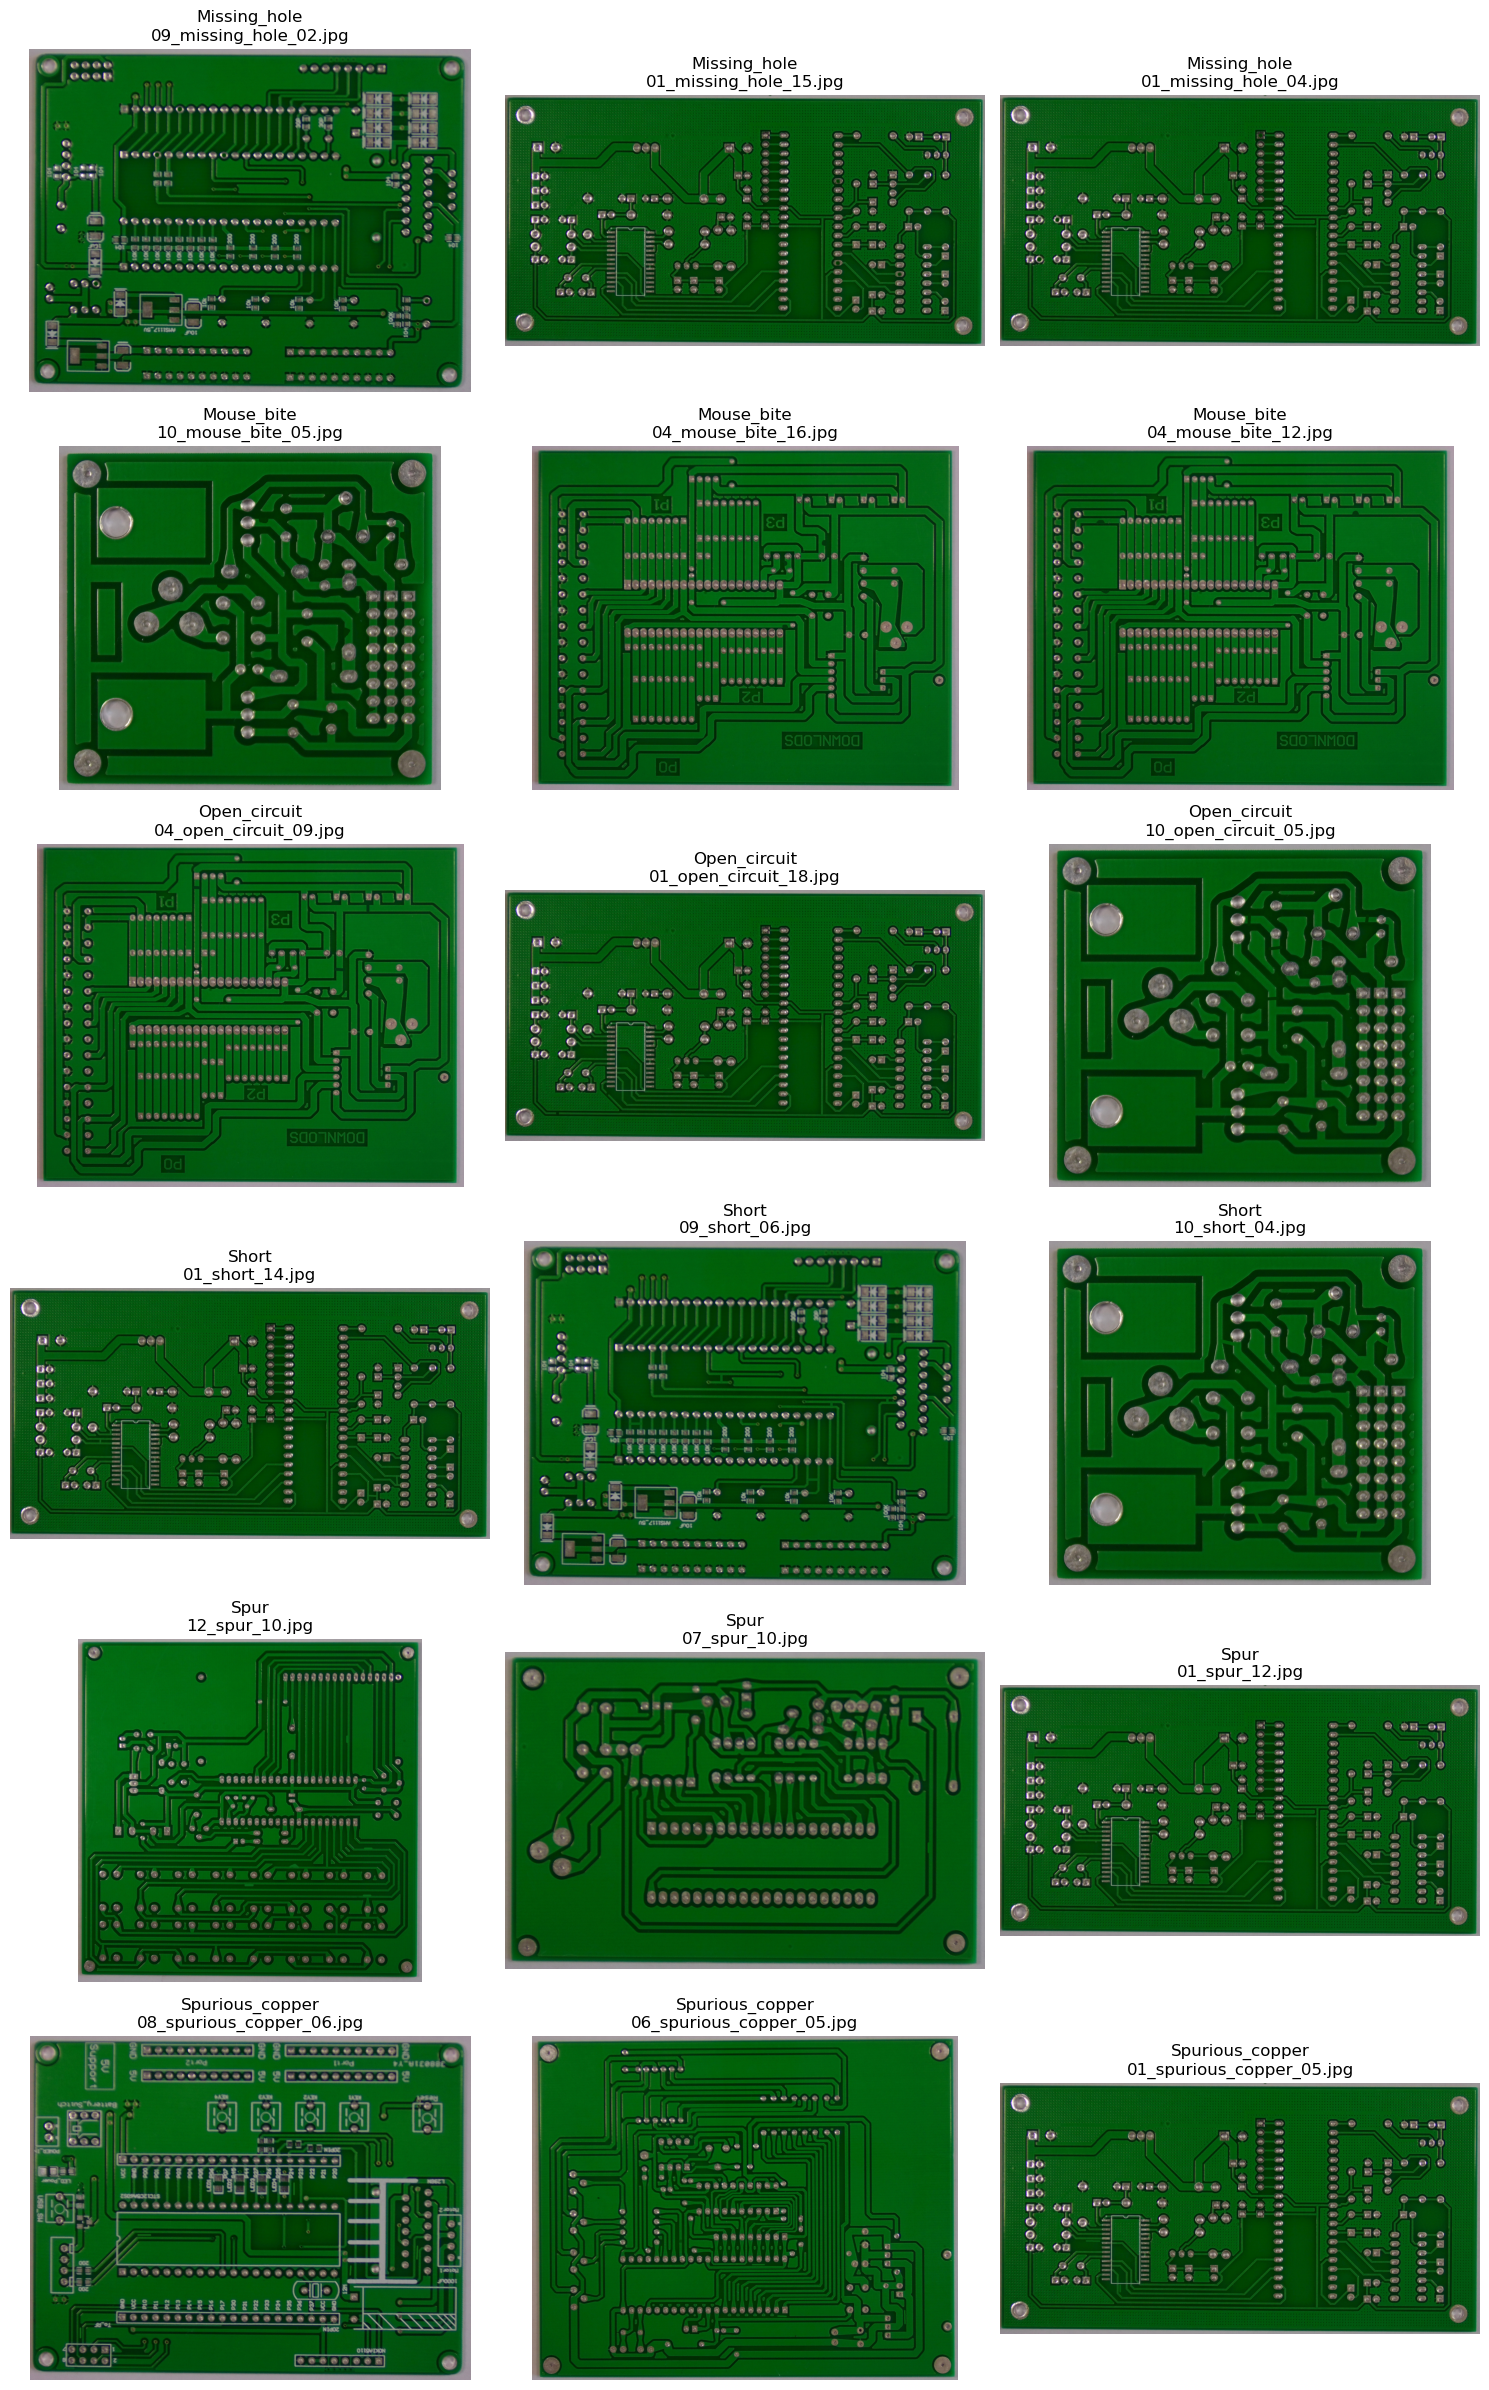

In [18]:
fig, axes = plt.subplots(
    len(class_folders),
    3,
    figsize=(15, 4 * len(class_folders))
)

for row, folder in enumerate(class_folders):

    files = [
        file for file in folder.rglob("*")
        if file.is_file()
        and file.suffix.lower() in IMAGE_EXTENSIONS
        and cv2.imread(str(file)) is not None
    ]

    selected = random.sample(files, min(3, len(files)))

    for col in range(3):

        ax = axes[row, col]

        if col < len(selected):
            image = cv2.imread(str(selected[col]))
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            ax.imshow(image)
            ax.set_title(f"{folder.name}\n{selected[col].name}")

        ax.axis("off")

plt.tight_layout()
plt.show()

In [19]:
suspicious_images = []

for path in image_files:
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)

    if image is None:
        continue

    std = np.std(image)

    # Very little pixel variation
    if std < 5:
        suspicious_images.append({
            "file": str(path.relative_to(RAW_DIR)),
            "std": std
        })

print("Potential blank/low-information images:",
      len(suspicious_images))

pd.DataFrame(suspicious_images).head(20)

Potential blank/low-information images: 0


""


In [20]:
report = {
    "Total image files": len(image_files),
    "Readable images": len(image_df),
    "Corrupted images": len(corrupted_files),
    "Exact duplicate groups": len(duplicate_groups),
    "Cross-class duplicate groups": len(cross_class_duplicates),
    "Suspicious low-information images": len(suspicious_images)
}

report_df = pd.DataFrame(
    report.items(),
    columns=["Check", "Result"]
)

report_df

,Check,Result
0,Total image files,693
1,Readable images,693
2,Corrupted images,0
3,Exact duplicate groups,0
4,Cross-class duplicate groups,0
5,Suspicious low-information images,0


In [21]:
REPORT_DIR = PROJECT_ROOT / "results"
REPORT_DIR.mkdir(exist_ok=True)

report_df.to_csv(
    REPORT_DIR / "dataset_cleaning_summary.csv",
    index=False
)

image_df.to_csv(
    REPORT_DIR / "image_inventory.csv",
    index=False
)

print("Reports saved.")

Reports saved.


In [22]:
from pathlib import Path
import random
from collections import defaultdict

SEED = 42
random.seed(SEED)

PROJECT_ROOT = Path.cwd().parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"
SPLIT_DIR = PROJECT_ROOT / "splits"

SPLIT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

print("Dataset:", RAW_DIR)
print("Exists:", RAW_DIR.exists())

Dataset: C:\Users\TARUMT\Downloads\PCB-Defect-Inspection\data\raw
Exists: True


In [23]:
class_images = defaultdict(list)

for class_folder in sorted(RAW_DIR.iterdir()):

    if not class_folder.is_dir():
        continue

    for file in class_folder.rglob("*"):

        if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS:
            class_images[class_folder.name].append(file)

for class_name, images in class_images.items():
    print(f"{class_name}: {len(images)} images")

Missing_hole: 115 images
Mouse_bite: 115 images
Open_circuit: 116 images
Short: 116 images
Spur: 115 images
Spurious_copper: 116 images


In [24]:
train_files = []
val_files = []
test_files = []

for class_name, images in class_images.items():

    images = images.copy()

    # Fixed shuffle
    random.Random(SEED).shuffle(images)

    total = len(images)

    train_end = int(total * 0.70)
    val_end = train_end + int(total * 0.15)

    train = images[:train_end]
    val = images[train_end:val_end]
    test = images[val_end:]

    train_files.extend(train)
    val_files.extend(val)
    test_files.extend(test)

    print(f"\n{class_name}")
    print("Train:", len(train))
    print("Val:  ", len(val))
    print("Test: ", len(test))


Missing_hole
Train: 80
Val:   17
Test:  18

Mouse_bite
Train: 80
Val:   17
Test:  18

Open_circuit
Train: 81
Val:   17
Test:  18

Short
Train: 81
Val:   17
Test:  18

Spur
Train: 80
Val:   17
Test:  18

Spurious_copper
Train: 81
Val:   17
Test:  18


In [25]:
total = len(train_files) + len(val_files) + len(test_files)

print("Total:", total)

print(
    f"Train: {len(train_files)} "
    f"({len(train_files)/total*100:.2f}%)"
)

print(
    f"Validation: {len(val_files)} "
    f"({len(val_files)/total*100:.2f}%)"
)

print(
    f"Test: {len(test_files)} "
    f"({len(test_files)/total*100:.2f}%)"
)

Total: 693
Train: 483 (69.70%)
Validation: 102 (14.72%)
Test: 108 (15.58%)


In [26]:
def save_split(files, output_file):

    with open(output_file, "w", encoding="utf-8") as f:

        for file in sorted(files):

            # Save path relative to raw dataset
            relative_path = file.relative_to(RAW_DIR)

            f.write(relative_path.as_posix() + "\n")

In [27]:
save_split(
    train_files,
    SPLIT_DIR / "train.txt"
)

save_split(
    val_files,
    SPLIT_DIR / "val.txt"
)

save_split(
    test_files,
    SPLIT_DIR / "test.txt"
)

print("Split files created!")

Split files created!


In [28]:
train_set = set(train_files)
val_set = set(val_files)
test_set = set(test_files)

print("Train ∩ Val:",
      len(train_set & val_set))

print("Train ∩ Test:",
      len(train_set & test_set))

print("Val ∩ Test:",
      len(val_set & test_set))

Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


In [29]:
all_split_files = train_set | val_set | test_set

print("Original images:", sum(len(v) for v in class_images.values()))
print("Images in split:", len(all_split_files))

Original images: 693
Images in split: 693


In [30]:
def get_distribution(files):

    distribution = defaultdict(int)

    for file in files:
        class_name = file.relative_to(RAW_DIR).parts[0]
        distribution[class_name] += 1

    return dict(sorted(distribution.items()))


print("TRAIN")
for name, count in get_distribution(train_files).items():
    print(name, count)

print("\nVALIDATION")
for name, count in get_distribution(val_files).items():
    print(name, count)

print("\nTEST")
for name, count in get_distribution(test_files).items():
    print(name, count)

TRAIN
Missing_hole 80
Mouse_bite 80
Open_circuit 81
Short 81
Spur 80
Spurious_copper 81

VALIDATION
Missing_hole 17
Mouse_bite 17
Open_circuit 17
Short 17
Spur 17
Spurious_copper 17

TEST
Missing_hole 18
Mouse_bite 18
Open_circuit 18
Short 18
Spur 18
Spurious_copper 18


In [36]:
annotation_class_folders = sorted([
    folder for folder in ANNOTATION_DIR.iterdir()
    if folder.is_dir()
])

for folder in annotation_class_folders:
    files = [f for f in folder.iterdir() if f.is_file()]

    print(f"\n{folder.name}")
    print("Number of files:", len(files))

    for file in files[:5]:
        print("  ", file.name)


Missing_hole
Number of files: 115
   01_missing_hole_01.xml
   01_missing_hole_02.xml
   01_missing_hole_03.xml
   01_missing_hole_04.xml
   01_missing_hole_05.xml

Mouse_bite
Number of files: 115
   01_mouse_bite_01.xml
   01_mouse_bite_02.xml
   01_mouse_bite_03.xml
   01_mouse_bite_04.xml
   01_mouse_bite_05.xml

Open_circuit
Number of files: 116
   01_open_circuit_01.xml
   01_open_circuit_02.xml
   01_open_circuit_03.xml
   01_open_circuit_04.xml
   01_open_circuit_05.xml

Short
Number of files: 116
   01_short_01.xml
   01_short_02.xml
   01_short_03.xml
   01_short_04.xml
   01_short_05.xml

Spur
Number of files: 115
   01_spur_01.xml
   01_spur_02.xml
   01_spur_03.xml
   01_spur_04.xml
   01_spur_05.xml

Spurious_copper
Number of files: 116
   01_spurious_copper_01.xml
   01_spurious_copper_02.xml
   01_spurious_copper_03.xml
   01_spurious_copper_04.xml
   01_spurious_copper_05.xml


In [37]:
from collections import Counter

annotation_extensions = Counter()

for folder in annotation_class_folders:
    for file in folder.rglob("*"):
        if file.is_file():
            annotation_extensions[file.suffix.lower()] += 1

print(annotation_extensions)

Counter({'.xml': 693})


In [38]:
import xml.etree.ElementTree as ET

xml_files = list(ANNOTATION_DIR.rglob("*.xml"))

print("XML annotations:", len(xml_files))

sample_xml = xml_files[0]

print("Sample:", sample_xml)

XML annotations: 693
Sample: C:\Users\TARUMT\Downloads\PCB-Defect-Inspection\data\raw\Annotations\Missing_hole\01_missing_hole_01.xml


In [39]:
tree = ET.parse(sample_xml)
root = tree.getroot()

ET.dump(root)

<annotation>
	<folder>Missing_hole</folder>
	<filename>01_missing_hole_01.jpg</filename>
	<path>/home/weapon/Desktop/PCB_DATASET/Missing_hole/01_missing_hole_01.jpg</path>
	<source>
		<database>Unknown</database>
	</source>
	<size>
		<width>3034</width>
		<height>1586</height>
		<depth>3</depth>
	</size>
	<segmented>0</segmented>
	<object>
		<name>missing_hole</name>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>2459</xmin>
			<ymin>1274</ymin>
			<xmax>2530</xmax>
			<ymax>1329</ymax>
		</bndbox>
	</object>
	<object>
		<name>missing_hole</name>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>1613</xmin>
			<ymin>334</ymin>
			<xmax>1679</xmax>
			<ymax>396</ymax>
		</bndbox>
	</object>
	<object>
		<name>missing_hole</name>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>1726</xmin>
			<ymin>794</ymin>
			<xmax>1797</xmax>
			<

In [40]:
missing_annotations = []
matched_pairs = []

for image_path in image_files:

    class_name = image_path.parent.name

    expected_annotation = (
        ANNOTATION_DIR /
        class_name /
        f"{image_path.stem}.xml"
    )

    if expected_annotation.exists():

        matched_pairs.append(
            (image_path, expected_annotation)
        )

    else:

        missing_annotations.append(image_path)

print("Images:", len(image_files))
print("Matched annotations:", len(matched_pairs))
print("Missing annotations:", len(missing_annotations))

Images: 693
Matched annotations: 693
Missing annotations: 0


In [41]:
image_stems = {
    (path.parent.name.lower(), path.stem.lower())
    for path in image_files
}

orphan_annotations = []

for annotation in ANNOTATION_DIR.rglob("*.xml"):

    class_name = annotation.parent.name.lower()

    key = (
        class_name,
        annotation.stem.lower()
    )

    if key not in image_stems:
        orphan_annotations.append(annotation)

print("Annotations without matching image:",
      len(orphan_annotations))

for annotation in orphan_annotations[:10]:
    print(annotation)

Annotations without matching image: 0


In [42]:
valid_classes = {
    "missing_hole",
    "mouse_bite",
    "open_circuit",
    "short",
    "spur",
    "spurious_copper"
}

annotation_problems = []

for image_path, annotation_path in matched_pairs:

    image = cv2.imread(str(image_path))

    if image is None:
        continue

    height, width = image.shape[:2]

    try:
        tree = ET.parse(annotation_path)
        root = tree.getroot()

        objects = root.findall("object")

        if len(objects) == 0:
            annotation_problems.append({
                "image": image_path.name,
                "problem": "No objects in annotation"
            })

        for obj in objects:

            class_name = obj.findtext("name")

            if class_name is None:
                annotation_problems.append({
                    "image": image_path.name,
                    "problem": "Missing class name"
                })
                continue

            class_name = class_name.strip().lower()

            if class_name not in valid_classes:
                annotation_problems.append({
                    "image": image_path.name,
                    "problem": f"Unexpected class: {class_name}"
                })

            box = obj.find("bndbox")

            if box is None:
                annotation_problems.append({
                    "image": image_path.name,
                    "problem": "Missing bounding box"
                })
                continue

            xmin = int(float(box.findtext("xmin")))
            ymin = int(float(box.findtext("ymin")))
            xmax = int(float(box.findtext("xmax")))
            ymax = int(float(box.findtext("ymax")))

            if xmin >= xmax or ymin >= ymax:
                annotation_problems.append({
                    "image": image_path.name,
                    "problem": "Invalid bounding box dimensions"
                })

            if xmin < 0 or ymin < 0 or xmax > width or ymax > height:
                annotation_problems.append({
                    "image": image_path.name,
                    "problem": "Bounding box outside image"
                })

    except Exception as e:

        annotation_problems.append({
            "image": image_path.name,
            "problem": str(e)
        })

print("Annotation problems:", len(annotation_problems))

pd.DataFrame(annotation_problems).head(20)

Annotation problems: 0


""


In [43]:
def show_annotation(image_path, annotation_path):

    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    tree = ET.parse(annotation_path)
    root = tree.getroot()

    plt.figure(figsize=(12, 7))
    plt.imshow(image)

    ax = plt.gca()

    for obj in root.findall("object"):

        label = obj.findtext("name")

        box = obj.find("bndbox")

        xmin = int(float(box.findtext("xmin")))
        ymin = int(float(box.findtext("ymin")))
        xmax = int(float(box.findtext("xmax")))
        ymax = int(float(box.findtext("ymax")))

        rectangle = plt.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            fill=False,
            linewidth=2
        )

        ax.add_patch(rectangle)

        ax.text(
            xmin,
            ymin,
            label,
            fontsize=10,
            backgroundcolor="white"
        )

    plt.title(image_path.name)
    plt.axis("off")
    plt.show()

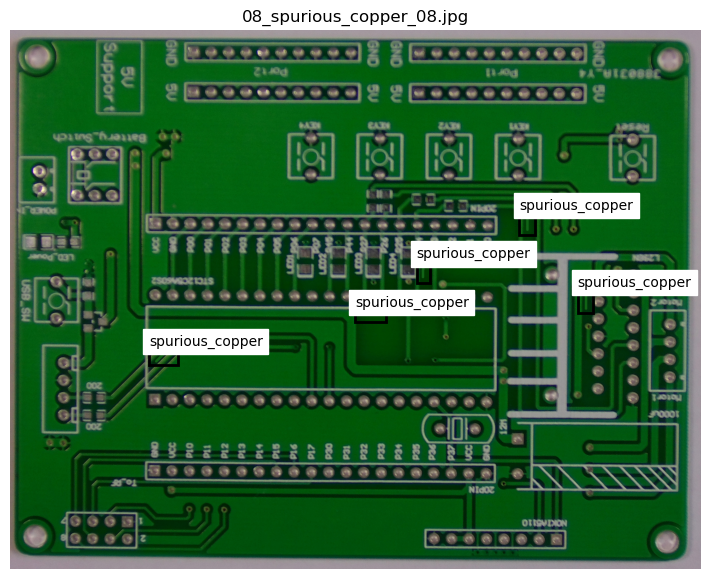

In [44]:
sample_image, sample_annotation = random.choice(matched_pairs)

show_annotation(
    sample_image,
    sample_annotation
)

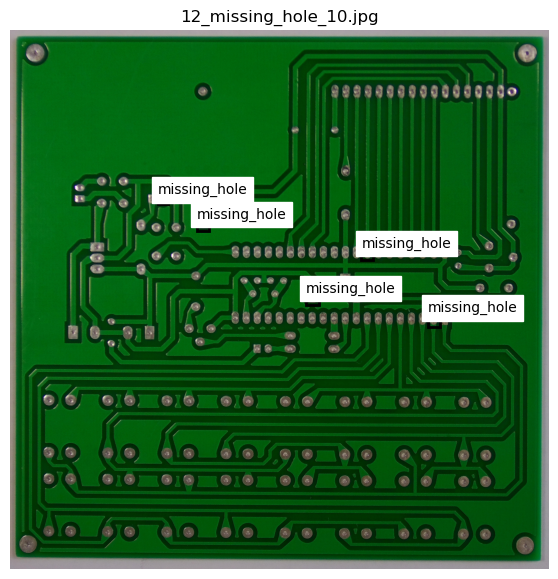

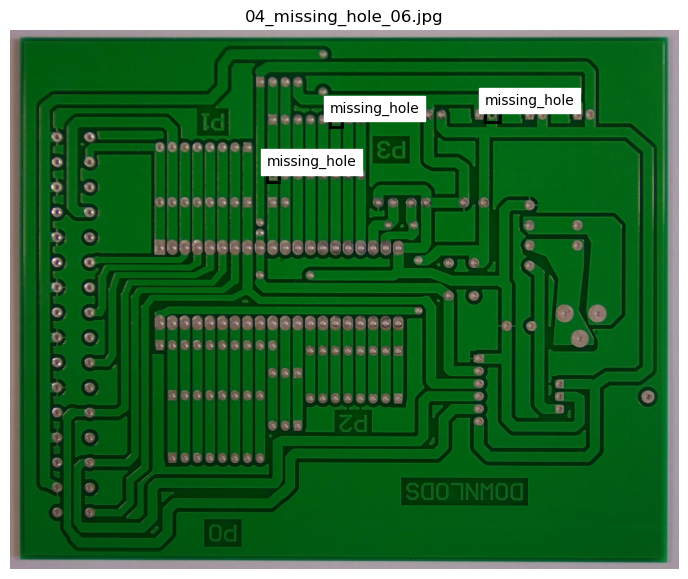

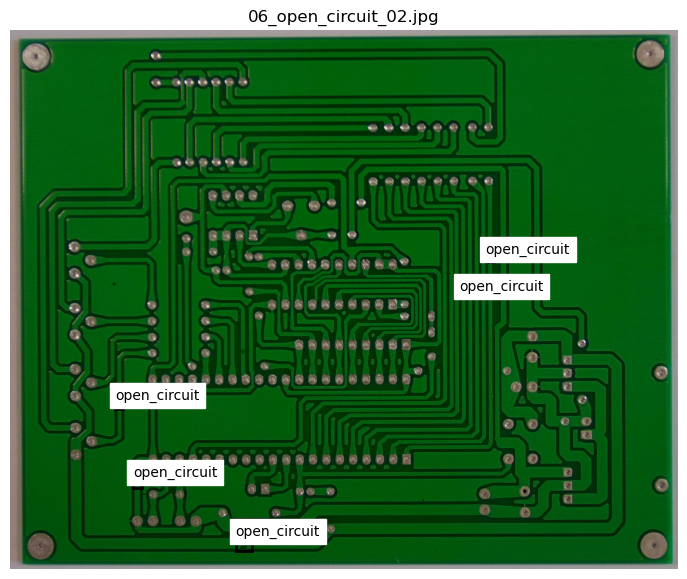

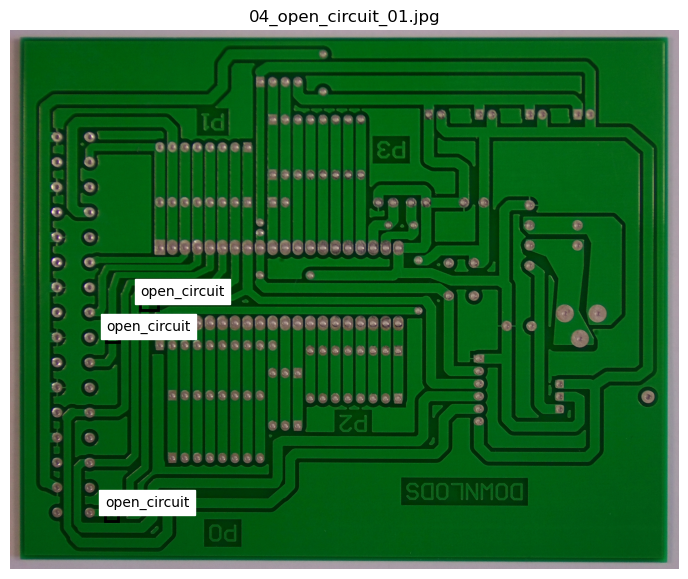

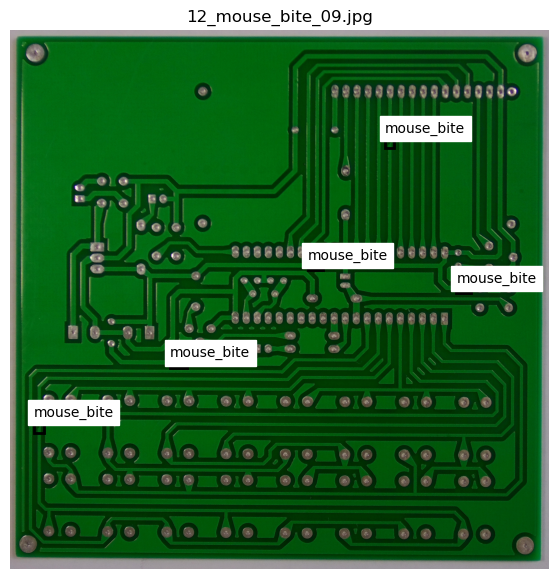

In [45]:
for image_path, annotation_path in random.sample(matched_pairs, 5):
    show_annotation(image_path, annotation_path)

In [46]:
def get_pcb_id(image_path):
    return image_path.stem.split("_")[0]


pcb_ids = sorted({
    get_pcb_id(path)
    for path in image_files
})

print("PCB IDs:")
print(pcb_ids)

print("\nNumber of PCB IDs:", len(pcb_ids))

PCB IDs:
['01', '04', '05', '06', '07', '08', '09', '10', '11', '12']

Number of PCB IDs: 10


In [47]:
pcb_counts = {}

for pcb_id in pcb_ids:

    pcb_counts[pcb_id] = sum(
        get_pcb_id(path) == pcb_id
        for path in image_files
    )

pcb_df = pd.DataFrame(
    pcb_counts.items(),
    columns=["PCB_ID", "Images"]
)

pcb_df

,PCB_ID,Images
0,01,120
1,04,120
2,05,60
3,06,61
4,07,60
5,08,60
6,09,60
7,10,32
8,11,60
9,12,60


In [48]:
reference_pcbs = {
    file.stem
    for file in PCB_DIR.iterdir()
    if file.is_file()
    and file.suffix.lower() in IMAGE_EXTENSIONS
}

print("PCB IDs in defective images:", len(pcb_ids))
print("PCB references:", len(reference_pcbs))

missing_references = set(pcb_ids) - reference_pcbs

print("Missing reference PCB IDs:",
      missing_references)

PCB IDs in defective images: 10
PCB references: 10
Missing reference PCB IDs: set()


In [49]:
print("Total images:", len(image_files))
print("Matched annotations:", len(matched_pairs))
print("Missing annotations:", len(missing_annotations))
print("Annotation problems:", len(annotation_problems))
print("PCB IDs:", pcb_ids)
print("Number of PCB IDs:", len(pcb_ids))
print("PCB references:", len(reference_pcbs))
print("Missing reference PCB IDs:", missing_references)

Total images: 693
Matched annotations: 693
Missing annotations: 0
Annotation problems: 0
PCB IDs: ['01', '04', '05', '06', '07', '08', '09', '10', '11', '12']
Number of PCB IDs: 10
PCB references: 10
Missing reference PCB IDs: set()


In [50]:
from collections import defaultdict

pcb_distribution = defaultdict(lambda: defaultdict(int))

for image_path in image_files:

    pcb_id = get_pcb_id(image_path)
    defect_class = image_path.parent.name

    pcb_distribution[pcb_id][defect_class] += 1


rows = []

for pcb_id in sorted(pcb_distribution):

    row = {"PCB_ID": pcb_id}

    total = 0

    for defect_class, count in pcb_distribution[pcb_id].items():
        row[defect_class] = count
        total += count

    row["Total"] = total
    rows.append(row)


pcb_class_df = pd.DataFrame(rows).fillna(0)

pcb_class_df

,PCB_ID,Missing_hole,Mouse_bite,Open_circuit,Short,Spur,Spurious_copper,Total
0,01,20,20,20,20,20,20,120
1,04,20,20,20,20,20,20,120
2,05,10,10,10,10,10,10,60
3,06,10,10,10,11,10,10,61
4,07,10,10,10,10,10,10,60
5,08,10,10,10,10,10,10,60
6,09,10,10,10,10,10,10,60
7,10,5,5,6,5,5,6,32
8,11,10,10,10,10,10,10,60
9,12,10,10,10,10,10,10,60


In [51]:
import itertools

pcb_image_counts = {
    pcb_id: sum(
        1 for image_path in image_files
        if get_pcb_id(image_path) == pcb_id
    )
    for pcb_id in pcb_ids
}

TOTAL_IMAGES = len(image_files)

best_split = None
best_score = float("inf")

# Choose 7 PCBs for training
for train_ids in itertools.combinations(pcb_ids, 7):

    remaining = [
        pcb for pcb in pcb_ids
        if pcb not in train_ids
    ]

    # Choose 1 of remaining for validation
    for val_ids in itertools.combinations(remaining, 1):

        test_ids = [
            pcb for pcb in remaining
            if pcb not in val_ids
        ]

        train_count = sum(
            pcb_image_counts[x] for x in train_ids
        )

        val_count = sum(
            pcb_image_counts[x] for x in val_ids
        )

        test_count = sum(
            pcb_image_counts[x] for x in test_ids
        )

        train_ratio = train_count / TOTAL_IMAGES
        val_ratio = val_count / TOTAL_IMAGES
        test_ratio = test_count / TOTAL_IMAGES

        score = (
            abs(train_ratio - 0.70)
            + abs(val_ratio - 0.10)
            + abs(test_ratio - 0.20)
        )

        if score < best_score:

            best_score = score

            best_split = {
                "train": train_ids,
                "val": val_ids,
                "test": tuple(test_ids),

                "train_count": train_count,
                "val_count": val_count,
                "test_count": test_count
            }

In [52]:
print("TRAIN PCB IDs:", best_split["train"])
print("VALIDATION PCB IDs:", best_split["val"])
print("TEST PCB IDs:", best_split["test"])

print()

print(
    "Train:",
    best_split["train_count"],
    f"({best_split['train_count']/TOTAL_IMAGES:.2%})"
)

print(
    "Validation:",
    best_split["val_count"],
    f"({best_split['val_count']/TOTAL_IMAGES:.2%})"
)

print(
    "Test:",
    best_split["test_count"],
    f"({best_split['test_count']/TOTAL_IMAGES:.2%})"
)

TRAIN PCB IDs: ('01', '05', '06', '07', '08', '09', '11')
VALIDATION PCB IDs: ('12',)
TEST PCB IDs: ('04', '10')

Train: 481 (69.41%)
Validation: 60 (8.66%)
Test: 152 (21.93%)


In [53]:
TRAIN_IDS = set(best_split["train"])
VAL_IDS = set(best_split["val"])
TEST_IDS = set(best_split["test"])


train_files = []
val_files = []
test_files = []


for image_path in image_files:

    pcb_id = get_pcb_id(image_path)

    if pcb_id in TRAIN_IDS:
        train_files.append(image_path)

    elif pcb_id in VAL_IDS:
        val_files.append(image_path)

    elif pcb_id in TEST_IDS:
        test_files.append(image_path)


print("Train images:", len(train_files))
print("Validation images:", len(val_files))
print("Test images:", len(test_files))

print("Total:",
      len(train_files) +
      len(val_files) +
      len(test_files))

Train images: 481
Validation images: 60
Test images: 152
Total: 693


In [54]:
train_pcb = {get_pcb_id(x) for x in train_files}
val_pcb = {get_pcb_id(x) for x in val_files}
test_pcb = {get_pcb_id(x) for x in test_files}

print("Train ∩ Validation:",
      train_pcb & val_pcb)

print("Train ∩ Test:",
      train_pcb & test_pcb)

print("Validation ∩ Test:",
      val_pcb & test_pcb)

Train ∩ Validation: set()
Train ∩ Test: set()
Validation ∩ Test: set()


In [55]:
print("All PCB IDs:",
      train_pcb | val_pcb | test_pcb)

print("Total PCB IDs:",
      len(train_pcb | val_pcb | test_pcb))

All PCB IDs: {'12', '01', '07', '08', '05', '06', '09', '11', '04', '10'}
Total PCB IDs: 10


In [56]:
def class_distribution(files):

    counts = defaultdict(int)

    for path in files:
        counts[path.parent.name] += 1

    return counts


distribution_df = pd.DataFrame({
    "Train": class_distribution(train_files),
    "Validation": class_distribution(val_files),
    "Test": class_distribution(test_files)
}).fillna(0).astype(int)

distribution_df

,Train,Validation,Test
Missing_hole,80,10,25
Mouse_bite,80,10,25
Open_circuit,80,10,26
Short,81,10,25
Spur,80,10,25
Spurious_copper,80,10,26


In [57]:
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

def save_split(files, filename):

    with open(SPLIT_DIR / filename, "w", encoding="utf-8") as f:

        for image_path in sorted(files):

            relative = image_path.relative_to(IMAGE_DIR)

            f.write(relative.as_posix() + "\n")


save_split(train_files, "train.txt")
save_split(val_files, "val.txt")
save_split(test_files, "test.txt")

print("Fixed split saved!")

Fixed split saved!


In [58]:
with open(SPLIT_DIR / "pcb_split.txt", "w") as f:

    f.write(
        "TRAIN: " +
        ", ".join(sorted(TRAIN_IDS)) +
        "\n"
    )

    f.write(
        "VALIDATION: " +
        ", ".join(sorted(VAL_IDS)) +
        "\n"
    )

    f.write(
        "TEST: " +
        ", ".join(sorted(TEST_IDS)) +
        "\n"
    )

print("PCB split saved.")

PCB split saved.


In [1]:
import sys
import cv2
import pandas as pd
import numpy as np
import matplotlib

print("Python:", sys.executable)
print("OpenCV:", cv2.__version__)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)

ModuleNotFoundError: No module named 'cv2'

In [2]:
%pip install opencv-python


   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/44.0 MB 774.6 kB/s eta 0:00:57
    --------------------------------------- 1.0/44.0 MB 1.5 MB/s eta 0:00:29
   - -------------------------------------- 1.6/44.0 MB 1.8 MB/s eta 0:00:23
   - -------------------------------------- 2.1/44.0 MB 1.9 MB/s eta 0:00:22
   -- ------------------------------------- 2.4/44.0 MB 1.8 MB/s eta 0:00:23
   -- ------------------------------------- 2.4/44.0 MB 1.8 MB/s eta 0:00:23
   -- ------------------------------------- 3.1/44.0 MB 1.7 MB/s eta 0:00:24
   --- ------------------------------------ 3.9/44.0 MB 1.9 MB/s eta 0:00:21
   ---- ----------------------------------- 4.5/44.0 MB 2.0 MB/s eta 0:00:20
   ---- ----------------------------------- 5.0/44.0 MB 2.0 MB/s eta 0:00:20
   ---- ----------

In [1]:
import sys
import cv2
import pandas as pd
import numpy as np
import matplotlib

print("Python:", sys.executable)
print("OpenCV:", cv2.__version__)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)

Python: c:\Users\szepi\anaconda3\python.exe
OpenCV: 5.0.0
Pandas: 2.2.3
NumPy: 2.1.3
Matplotlib: 3.10.0
